In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

100%|██████████| 172k/172k [00:00<00:00, 61.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [4]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1"

print(os.listdir(dataset_path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [5]:
import pandas as pd

file_path = "/root/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.info()
df["Churn"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count
Churn,
No,5174
Yes,1869


In [13]:
df["TotalCharges"].head()

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [15]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [16]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [17]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [20]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [21]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [22]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


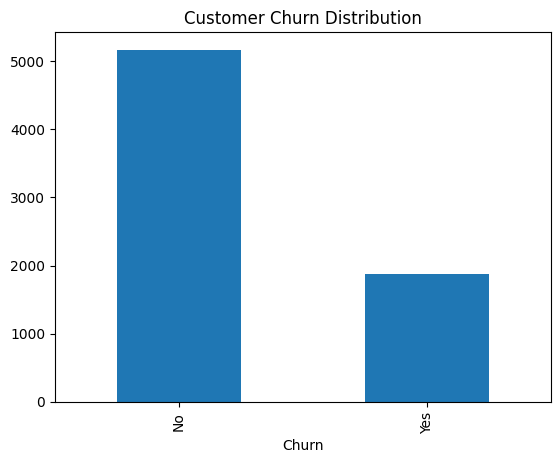

In [23]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.show()

In [24]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


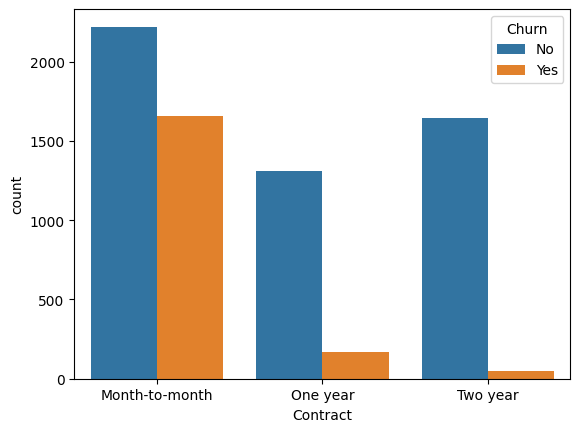

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.show()

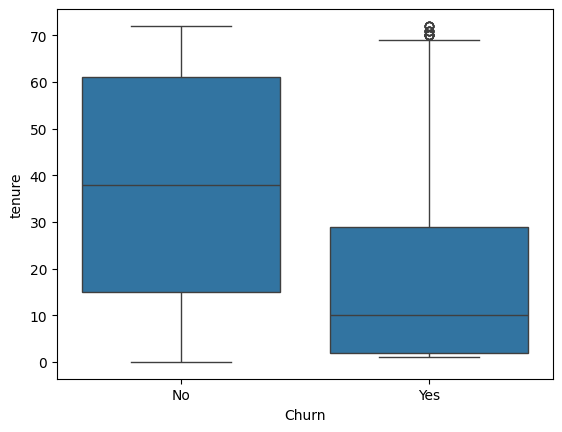

In [26]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.show()

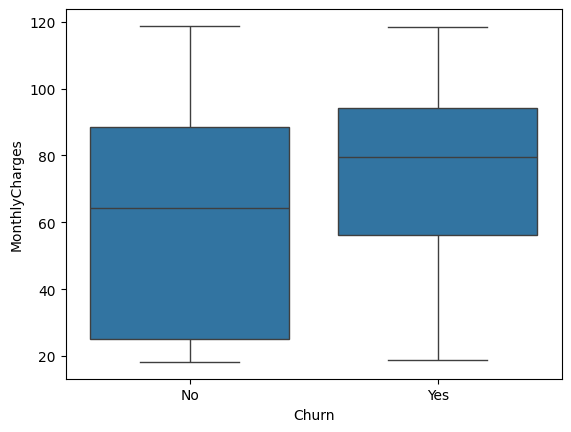

In [27]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

In [28]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [29]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [30]:
temp_df = df.copy()

for col in temp_df.select_dtypes(include="object"):
    temp_df[col] = temp_df[col].astype("category").cat.codes

In [31]:
corr = temp_df.corr()

corr["Churn"].sort_values(ascending=False)

,Churn
Churn,1.000000
MonthlyCharges,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
PaymentMethod,0.107062
MultipleLines,0.038037
PhoneService,0.011942
gender,-0.008612
customerID,-0.017447
StreamingTV,-0.036581


# Customer Churn Analysis - Key Findings

## Dataset Overview
- Total Customers: 7043
- Target Variable: Churn
- Churn Rate: ~27%
- Retention Rate: ~73%

## Key Findings

### 1. Contract Type and Churn
- Customers on Month-to-Month contracts exhibit the highest churn rates.
- Customers with One-Year and Two-Year contracts are significantly less likely to churn.
- Long-term contracts appear to improve customer retention.

### 2. Tenure and Churn
- Customers with shorter tenure are more likely to leave.
- Long-term customers generally show higher loyalty and lower churn rates.

### 3. Monthly Charges and Churn
- Customers paying higher monthly charges tend to churn more frequently.
- Pricing may be a contributing factor to customer dissatisfaction.

### 4. Internet Service and Churn
- Fiber Optic customers show higher churn rates compared to other internet service categories.
- Further investigation may be required to identify service-related issues.

### 5. Senior Citizens
- Senior citizens appear to have a different churn pattern compared to non-senior customers.
- This customer segment may require targeted retention strategies.

## Business Recommendations

1. Encourage customers to move from Month-to-Month to long-term contracts.
2. Focus retention efforts on new customers during the first few months.
3. Investigate causes of churn among high-paying customers.
4. Analyze customer experience for Fiber Optic users.
5. Develop personalized retention campaigns for high-risk customer groups.

## Next Steps

- Perform feature engineering.
- Train an XGBoost churn prediction model.
- Evaluate model performance using Precision, Recall, F1 Score, and ROC-AUC.
- Apply SHAP explainability to understand model decisions.
- Build an interactive Streamlit dashboard for business users.

In [32]:
df_model = df.copy()

In [33]:
df_model.drop("customerID", axis=1, inplace=True)

In [34]:
df_model["Churn"] = df_model["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [35]:
df_model["Churn"].head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [36]:
df_model.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [37]:
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

In [38]:
print(df_model.shape)

(7043, 31)


In [39]:
X = df_model.drop("Churn", axis=1)

y = df_model["Churn"]

In [41]:
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
!pip install xgboost

In [45]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [47]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7984386089425124
Precision: 0.6461038961038961
Recall   : 0.5320855614973262
F1 Score : 0.5835777126099707
ROC AUC  : 0.8423480327572399


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [175 199]]


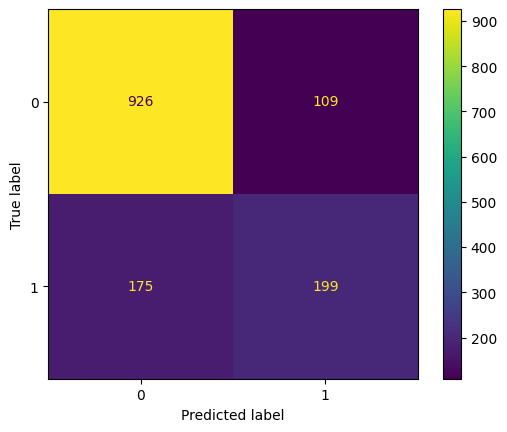

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [51]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
10,InternetService_Fiber optic,0.352537
25,Contract_Two year,0.205334
24,Contract_One year,0.152578
11,InternetService_No,0.060253
23,StreamingMovies_Yes,0.031409
1,tenure,0.028598
28,PaymentMethod_Electronic check,0.017072
9,MultipleLines_Yes,0.014904
19,TechSupport_Yes,0.013498
13,OnlineSecurity_Yes,0.013306


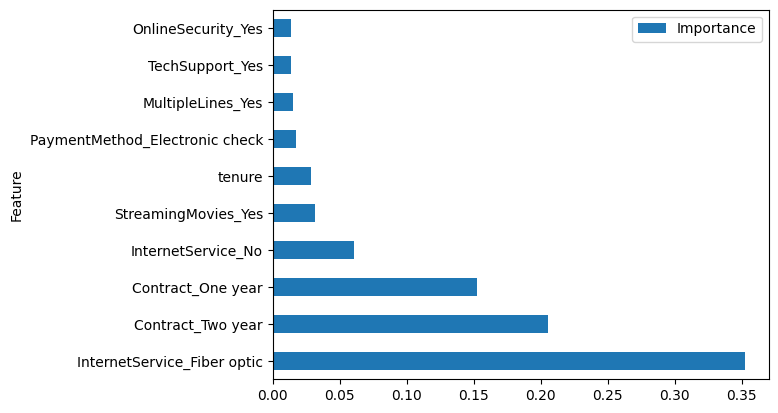

In [52]:
import matplotlib.pyplot as plt

importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.show()

In [53]:
!pip install shap

In [54]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

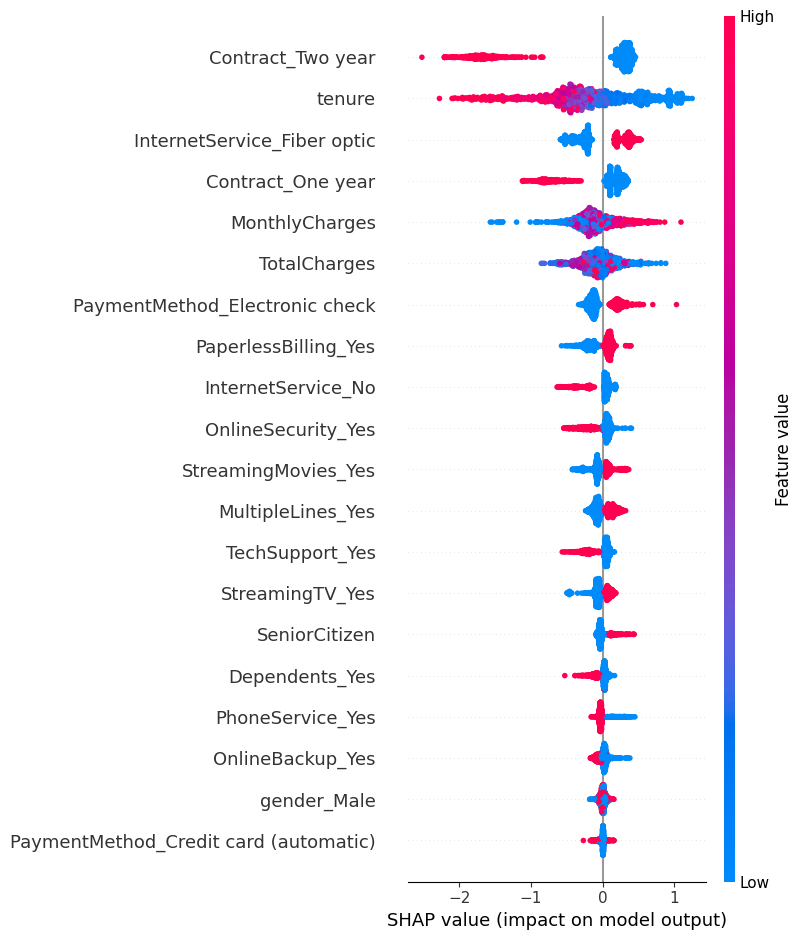

In [55]:
shap.summary_plot(
    shap_values,
    X_test
)

In [56]:
!pip install shap

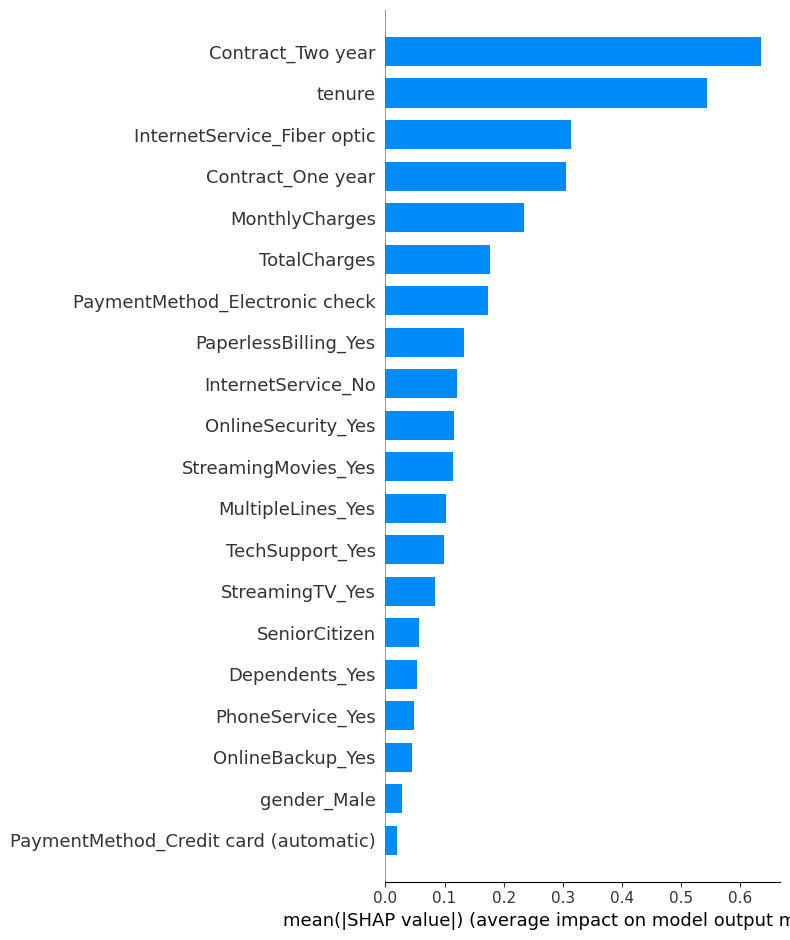

In [60]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [61]:
customer = X_test.iloc[[0]]

In [62]:
shap_values_single = explainer.shap_values(customer)

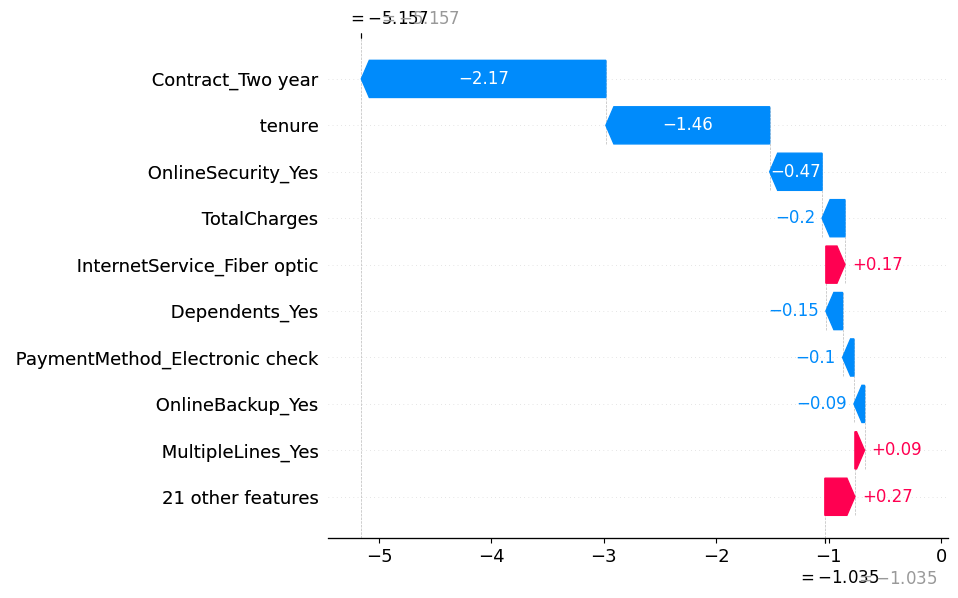

In [63]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values_single[0],
    customer.iloc[0]
)

In [65]:
import joblib

joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [66]:
joblib.dump(
    X.columns.tolist(),
    "features.pkl"
)

['features.pkl']

# Model Results

Accuracy: 79.8%
Precision: 64.6%
Recall: 53.2%
F1 Score: 58.4%
ROC-AUC: 84.2%

# Key Drivers of Churn

1. Month-to-Month Contract
2. Short Customer Tenure
3. High Monthly Charges
4. Fiber Optic Internet Service
5. Lack of Technical Support

# Business Impact

The model can identify high-risk customers and provide feature-level explanations, enabling targeted retention strategies and reducing customer attrition.